# Modelo JoinPoint (Borrador)

In [4]:
# [Librerías Importadas]

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
from sklearn.model_selection import train_test_split
import pwlf


In [12]:
df = pd.read_csv("C:\Dengue_caracterization\DATA_LAST\Datos Modelos\datos_completos.csv")
print(df.head())

  municipio   año  periodo  periodo_continuo  casos  ciclo_vital_adolescencia  \
0   BARANOA  2018        2                 2      1                       1.0   
1   BARANOA  2018        4                 4      1                       0.0   
2   BARANOA  2018        5                 5      1                       0.0   
3   BARANOA  2018        6                 6      2                       0.0   
4   BARANOA  2018        7                 7      3                       0.0   

   ciclo_vital_adulto  ciclo_vital_adulto_mayor  ciclo_vital_infante_mayor  \
0            0.000000                       0.0                   0.000000   
1            1.000000                       0.0                   0.000000   
2            1.000000                       0.0                   0.000000   
3            1.000000                       0.0                   0.000000   
4            0.333333                       0.0                   0.666667   

   ciclo_vital_infante_menor  ...  dist_lago

In [13]:
df = df.drop(columns=['ciclo_vital_infante_mayor','año','periodo'])

## Correlación y Colinealidad

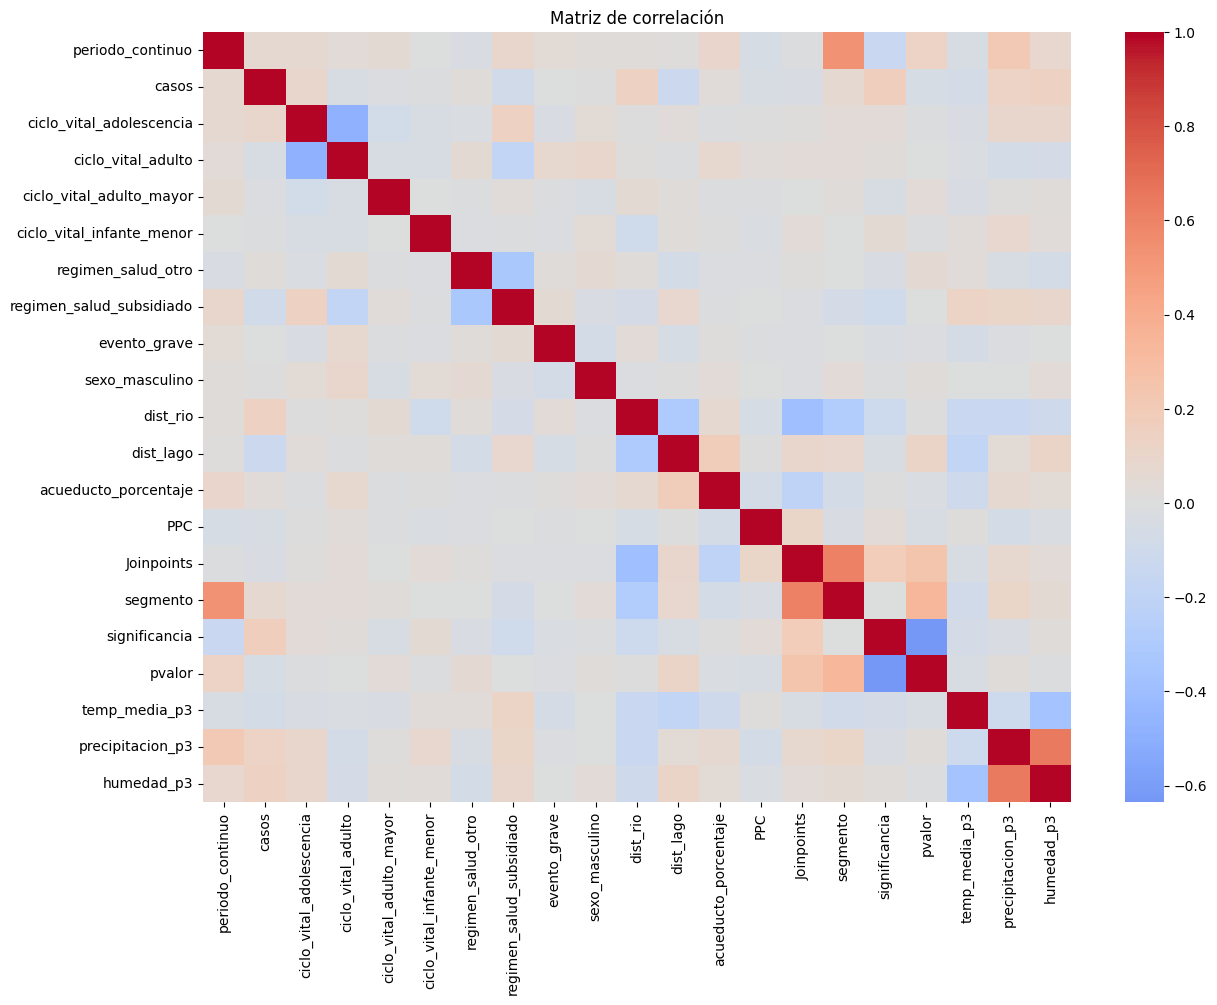

PPC                          1.000000
Joinpoints                   0.103049
significancia                0.035812
ciclo_vital_adulto           0.023940
temp_media_p3                0.016039
ciclo_vital_adolescencia     0.006693
dist_lago                    0.006233
sexo_masculino              -0.002508
regimen_salud_subsidiado    -0.007401
evento_grave                -0.010828
ciclo_vital_adulto_mayor    -0.010903
regimen_salud_otro          -0.017023
humedad_p3                  -0.024803
ciclo_vital_infante_menor   -0.028014
segmento                    -0.036046
casos                       -0.044311
pvalor                      -0.045548
dist_rio                    -0.049753
periodo_continuo            -0.050745
precipitacion_p3            -0.066813
acueducto_porcentaje        -0.070958
Name: PPC, dtype: float64


In [14]:
# [Correlación entre Variables]

# Nos quedamos solo con variables numéricas
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Correlación
corr = num_cols.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de correlación")
plt.show()

# Correlaciones respecto a REM
corr_REM = corr['PPC'].sort_values(ascending=False)
print(corr_REM)

In [16]:
# Variables predictoras (excluir REM y variables categóricas como municipio)
df_vif = df.drop(columns=['PPC', 'municipio','periodo_continuo'])

# Dataset limpio de NaN
df_vif = df_vif.dropna()

# Calcular VIF
vif = pd.DataFrame()
vif["variable"] = df_vif.columns
vif["VIF"] = [variance_inflation_factor(df_vif.values, i)
              for i in range(df_vif.shape[1])]

display(vif.sort_values(by="VIF", ascending=False))

,variable,VIF
18,humedad_p3,652.115441
16,temp_media_p3,583.670299
11,acueducto_porcentaje,49.302939
12,Joinpoints,8.809613
14,significancia,6.143050
9,dist_rio,5.780774
6,regimen_salud_subsidiado,5.419764
17,precipitacion_p3,5.254322
8,sexo_masculino,3.795018
10,dist_lago,3.792072


## Prueba Modelo

In [29]:
import statsmodels.api as sm
import pandas as pd

df = pd.read_csv("C:\Dengue_caracterization\DATA_LAST\Datos Modelos\datos_completos.csv")


In [30]:


df = df.drop(columns=['ciclo_vital_infante_mayor','año','periodo','pvalor'])

df.columns

Index(['municipio', 'periodo_continuo', 'casos', 'ciclo_vital_adolescencia',
       'ciclo_vital_adulto', 'ciclo_vital_adulto_mayor',
       'ciclo_vital_infante_menor', 'regimen_salud_otro',
       'regimen_salud_subsidiado', 'evento_grave', 'sexo_masculino',
       'dist_rio', 'dist_lago', 'acueducto_porcentaje', 'PPC', 'Joinpoints',
       'segmento', 'significancia', 'temp_media_p3', 'precipitacion_p3',
       'humedad_p3'],
      dtype='object')

In [ ]:
# Convierto 'segmento' a categórica
df['segmento'] = df['segmento'].astype('category')
df['significancia'] = df['significancia'].astype('category')    


In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pymc_spatial import CAR

# cargar datos
df["municipio_id"] = df["municipio"].astype("category").cat.codes

# leer shapefile
gdf = gpd.read_file("municipios.shp")
gdf = gdf.sort_values("municipio")  # que coincida con df

# matriz de vecinos (W)
from libpysal.weights import Queen
w = Queen.from_dataframe(gdf)
W = w.full()[0]      # matriz binaria NxN



In [ ]:
import statsmodels.formula.api as smf


In [32]:
import pandas as pd
import plotly.graph_objects as go

df_seg = pd.read_csv(r"C:\Dengue_caracterization\DATA_LAST\JoinPoint Results\Total.Export.APC.txt")
df_data = pd.read_csv(r"C:\Dengue_caracterization\DATA_LAST\JoinPoint Results\Total.Export.Data.txt")

municipio = "BARANOA"

seg = df_seg[df_seg["municipio"] == municipio].copy()
dat = df_data[df_data["municipio"] == municipio].copy()

dat = dat.sort_values("periodo_global")

fig = go.Figure()

# 1. Observado
fig.add_trace(go.Scatter(
    x=dat["periodo_global"],
    y=dat["REM"],
    mode="markers",
    marker=dict(color="darkred", size=7),
    name="Observado"
))

# 2. Segmentos
colors = ["blue", "green", "red", "purple", "orange"]

for i, row in seg.iterrows():

    ini = row["Segment Start"]
    fin = row["Segment End"]

    tramo = dat[(dat["periodo_global"] >= ini) & (dat["periodo_global"] <= fin)]

    fig.add_trace(go.Scatter(
        x=tramo["periodo_global"],
        y=tramo["Model"],
        mode="lines",
        line=dict(width=3, color=colors[int(row['Segment']) % len(colors)]),
        name=f"Segmento {row['Segment']}"
    ))

# Formato
fig.update_layout(
    title=f"Joinpoint model – {municipio}",
    xaxis_title="periodo_global",
    yaxis_title="REM",
    template="plotly_white"
)

fig.show()


c:\Users\TAWTOCA\anaconda3\envs\machine\lib\site-packages\kaleido\__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.


